In [31]:
import pandas as pd 

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
path = r"H:\Python\Etapa3\analiseDados\AnaliseTabela4\CD2022_Populacao_2010_Compatibilizada_20231222.xlsx"

In [35]:
dados_brutos = pd.read_excel(path, header=2)

In [36]:
tabela_tratada = dados_brutos.iloc[0:5570,1:]

In [37]:
tabela_tratada.columns

Index(['UF', 'COD. UF', 'COD. MUNIC', 'NOME DO MUNICÍPIO',
       'População Município 2010\n(Sinopse)',
       'População 2010 (Alterações de Limites até 2022)1',
       'População Censo 2022'],
      dtype='str')

In [38]:
tabela_tratada

,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,População Município 2010\n(Sinopse),População 2010 (Alterações de Limites até 2022)1,População Censo 2022
0,RO,11.0,15.0,Alta Floresta D'Oeste,24392.0,24392.0,21494.0
1,RO,11.0,23.0,Ariquemes,90353.0,90353.0,96833.0
2,RO,11.0,31.0,Cabixi,6313.0,6313.0,5351.0
3,RO,11.0,49.0,Cacoal,78574.0,78574.0,86887.0
4,RO,11.0,56.0,Cerejeiras,17029.0,17029.0,15890.0
...,...,...,...,...,...,...,...
5565,GO,52.0,22005.0,Vianópolis,12548.0,12548.0,14956.0
5566,GO,52.0,22054.0,Vicentinópolis,7371.0,7373.0,8768.0
5567,GO,52.0,22203.0,Vila Boa,4735.0,4735.0,4215.0
5568,GO,52.0,22302.0,Vila Propício,5145.0,5145.0,5815.0


In [39]:
# 5. Crie uma tabela de população agregada por estado
pop_estado = dados_brutos.groupby("UF")[["População 2010 (Alterações de Limites até 2022)1", "População Censo 2022"]].sum().reset_index()

# Faz a diferença (crescimento populacional)
pop_estado["diferenca"] = pop_estado["População Censo 2022"] - pop_estado["População 2010 (Alterações de Limites até 2022)1"]

In [40]:
# 6. Organize essa tabela por população que mais cresceu (Decrescente)
pop_estado_ordenado = pop_estado.sort_values(by="diferenca", ascending=False)

In [41]:
# 7. Salve essa tabela nova em csv na pasta do seu projeto
pop_estado_ordenado.to_csv("populacao_agregada_estado.csv", sep=";", index=False)

In [42]:
pop_estado_ordenado

,UF,População 2010 (Alterações de Limites até 2022)1,População Censo 2022,diferenca
27,SP,41262199.0,44411238.0,3149039.0
25,SC,6248436.0,7610361.0,1361925.0
9,GO,6001789.0,7056495.0,1054706.0
19,PR,10444526.0,11444380.0,999854.0
11,MG,19597330.0,20539989.0,942659.0
13,MT,3035122.0,3658649.0,623527.0
15,PA,7581051.0,8120131.0,539080.0
2,AM,3483985.0,3941613.0,457628.0
5,CE,8451644.0,8794957.0,343313.0
7,ES,3514952.0,3833712.0,318760.0


In [43]:
# 8. Agora trabalhe por município
# Faz a diferença diretamente na tabela bruta
dados_brutos["diferenca"] = dados_brutos["População Censo 2022"] - dados_brutos["População 2010 (Alterações de Limites até 2022)1"]

In [44]:
# 9. Organize essa tabela por população que mais cresceu (Decrescente)
pop_municipio_ordenado = dados_brutos.sort_values(by="diferenca", ascending=False)

In [45]:
# 10. Salve essa tabela nova em csv na pasta do seu projeto
pop_municipio_ordenado.to_csv("populacao_municipio_ordenado.csv", sep=";", index=False)

In [50]:
pop_municipio_ordenado


,Unnamed: 0,UF,COD. UF,COD. MUNIC,NOME DO MUNICÍPIO,População Município 2010\n(Sinopse),População 2010 (Alterações de Limites até 2022)1,População Censo 2022,diferenca
111,NaN,AM,13.0,2603.0,Manaus,1802014.0,1802014.0,2063689.0,261675.0
5569,NaN,DF,53.0,108.0,Brasília,2570160.0,2572159.0,2817381.0,245222.0
3829,NaN,SP,35.0,50308.0,São Paulo,11253503.0,11253503.0,11451999.0,198496.0
3848,NaN,SP,35.0,52205.0,Sorocaba,586625.0,586816.0,723682.0,136866.0
5417,NaN,GO,52.0,8707.0,Goiânia,1302001.0,1301912.0,1437366.0,135454.0
...,...,...,...,...,...,...,...,...,...
2162,NaN,BA,29.0,27408.0,Salvador,2675656.0,2675656.0,2417678.0,-257978.0
5570,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5571,NaN,Nota: Para o cálculo das taxas de crescimento ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5572,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


C:\Users\12500380\AppData\Local\Temp\ipykernel_10152\2376989187.py:8: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


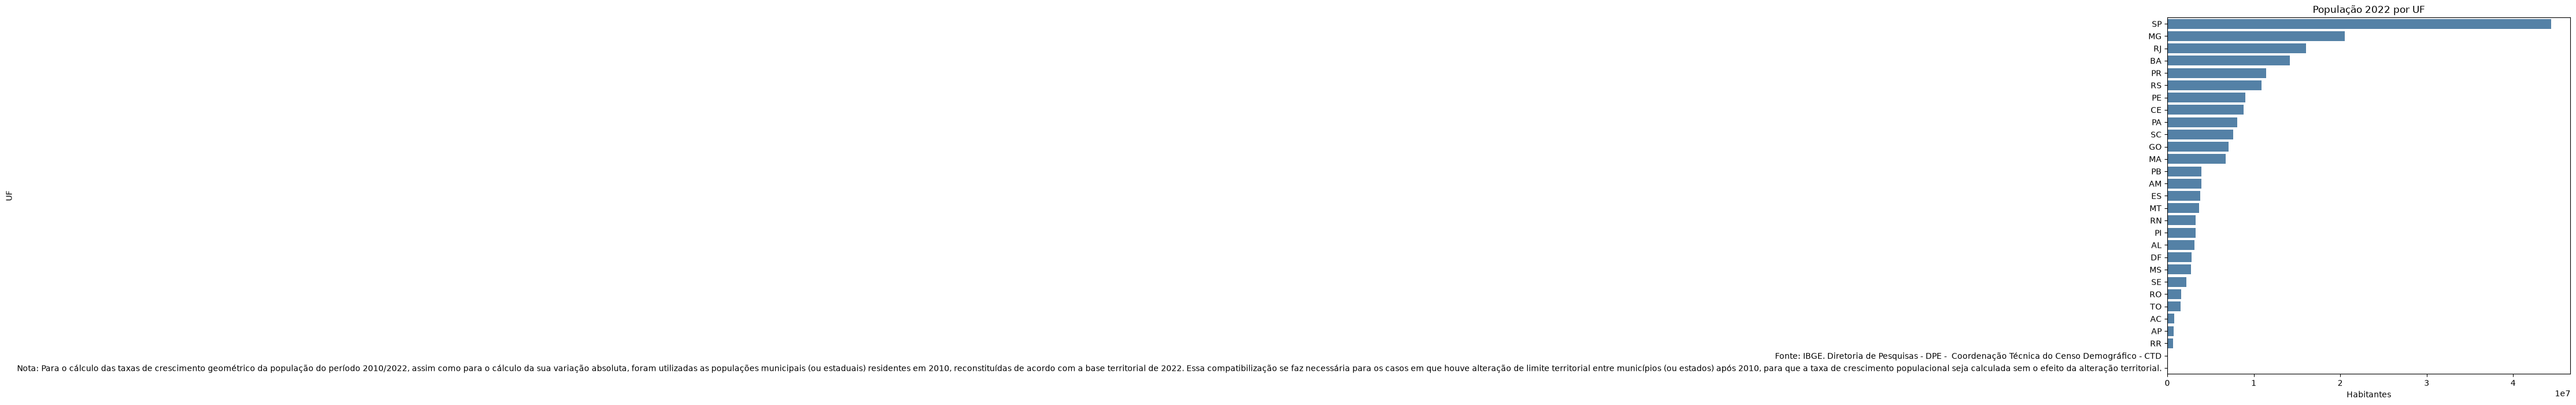

In [73]:
#Barras: população 2022 por UF
fig, ax = plt.subplots(figsize=(9, 8))
ordem = pop_estado_ordenado.sort_values("População Censo 2022", ascending=False)
sns.barplot(data=ordem, y="UF", x="População Censo 2022", ax=ax, color="steelblue")
ax.set_title("População 2022 por UF")
ax.set_xlabel("Habitantes")
ax.set_ylabel("UF")
plt.tight_layout()
plt.show()